<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/exercise3_univariate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import, visualize and summarize table properties

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/olawaleaboderin/greends-avcad-2026/main/examples/EFIplus_medit.zip', sep=";")
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5011, 164)


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


Clean and reajust the dataset

In [4]:
# clean up the dataset to remove unnecessary columns (eg. REG)
df.drop(df.iloc[:,5:15], axis=1, inplace=True) # axis=1 - columns; inplace=True - the changes will be saved to the original data frame.

# for consistency, let's also make all column labels of type string
df.columns = list(map(str, df.columns))

In [5]:
# Check data types
pd.options.display.max_rows = 154 # maximum number of rows displayed.
df.dtypes

,0
Site_code,object
Latitude,float64
Longitude,float64
Country,object
Catchment_name,object
Water_source_type,object
Flow_regime,object
Altitude,int64
Geological_typology,object
Actual_river_slope,float64


In [6]:
# Number of values per variable
df.count()

,0
Site_code,5011
Latitude,5011
Longitude,5011
Country,5011
Catchment_name,5011
Water_source_type,4712
Flow_regime,4473
Altitude,5011
Geological_typology,5011
Actual_river_slope,4975


Handling missing data

In [7]:
# Check missing values
df[['Catchment_name','Site_code','temp_ann']].isnull().sum()


,0
Catchment_name,0
Site_code,0
temp_ann,170


In [8]:
# Remove rows where temp_ann is missing
df = df.dropna(subset=['temp_ann'])

In [9]:
# Check the dataset shape after dropping missing values
print("Number of rows and columns after removing missing temp_ann values:", df.shape)

Number of rows and columns after removing missing temp_ann values: (4841, 154)


Identify Catchments with the Highest Number of Sampling Sites

In [10]:
# Count number of sampling sites per catchment
catchment_counts = df.groupby("Catchment_name")["Site_code"].count()

# Sort in descending order
catchment_counts = catchment_counts.sort_values(ascending=False)

# Display the top catchments
print(catchment_counts.head(10))

Catchment_name
Ebro            715
Galiza-Norte    709
Minho           707
Tejo            493
Cantabrica      432
Douro           396
Guadia          307
Catala          217
Tevere          101
Jucar            97
Name: Site_code, dtype: int64


Select the Top 4 Catchments

In [11]:
top4_catchments = catchment_counts.head(4).index

print("Top 4 catchments with highest number of fish sampling sites:")
print(top4_catchments)

Top 4 catchments with highest number of fish sampling sites:
Index(['Ebro', 'Galiza-Norte', 'Minho', 'Tejo'], dtype='object', name='Catchment_name')


Filter Dataset for the Top Catchments

In [12]:
df_top4 = df[df["Catchment_name"].isin(top4_catchments)]

df_top4.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Water_source_type,Flow_regime,Altitude,Geological_typology,Actual_river_slope,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,Groundwater,Permanent,1253,Calcareous,13.406,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,Groundwater,Permanent,1155,Calcareous,9.398,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,Groundwater,Permanent,1074,Calcareous,8.186,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,Groundwater,Permanent,1018,Calcareous,11.736,...,0,0,0,0,0,0,0,0,0,0
5,ES_02_0005,40.732830,-2.078003,Spain,Tejo,Pluvial,Permanent,979,Calcareous,2.670,...,0,0,0,0,0,0,0,0,0,0


Summary Statistics of the data

In [13]:
df_top4.groupby("Catchment_name")["temp_ann"].describe()

,count,mean,std,min,25%,50%,75%,max
Catchment_name,,,,,,,,
Ebro,715.0,11.453846,2.273707,3.9,10.4,11.9,12.9,16.9
Galiza-Norte,709.0,13.435825,0.891271,9.2,12.9,13.5,14.1,15.0
Minho,707.0,11.858416,1.623498,6.9,10.8,12.2,12.8,15.0
Tejo,493.0,14.242596,2.422827,8.0,12.8,15.0,16.2,17.2


Boxplot of Annual Mean Temperature

/tmp/ipykernel_892/1513558457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


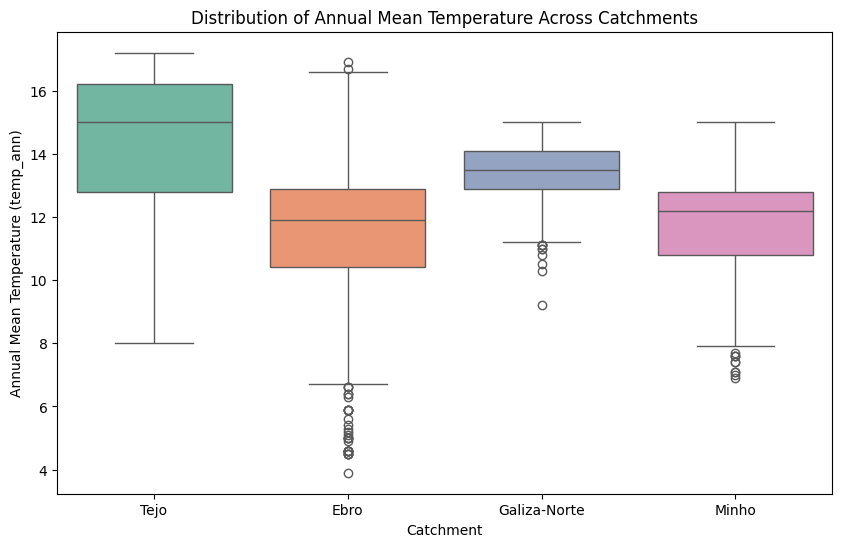

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_top4,
    x="Catchment_name",
    y="temp_ann",
    palette="Set2"
)

plt.title("Distribution of Annual Mean Temperature Across Catchments")
plt.xlabel("Catchment")
plt.ylabel("Annual Mean Temperature (temp_ann)")

plt.show()

Strip Plot of Annual mean Temperature

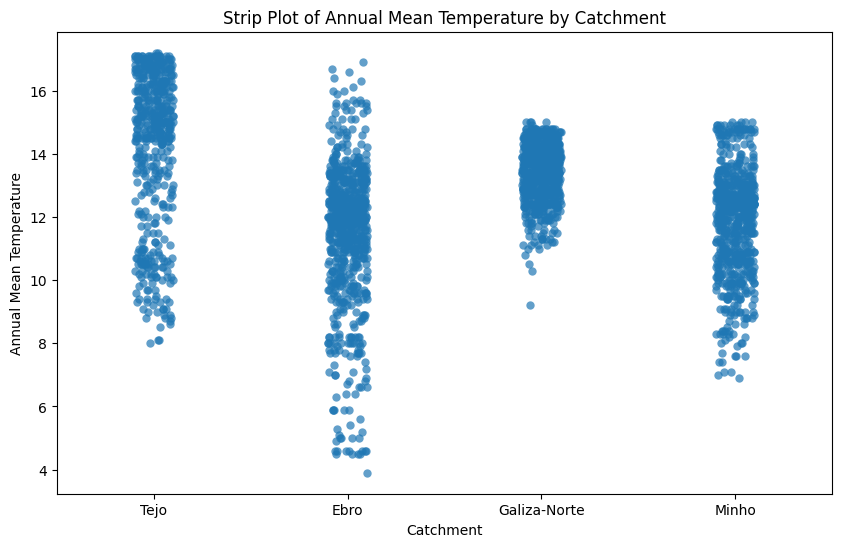

In [15]:
plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_top4,
    x="Catchment_name",
    y="temp_ann",
    jitter=True,
    size=6,
    alpha=0.7
)

plt.title("Strip Plot of Annual Mean Temperature by Catchment")
plt.xlabel("Catchment")
plt.ylabel("Annual Mean Temperature")

plt.show()

Histograms for Each Catchment

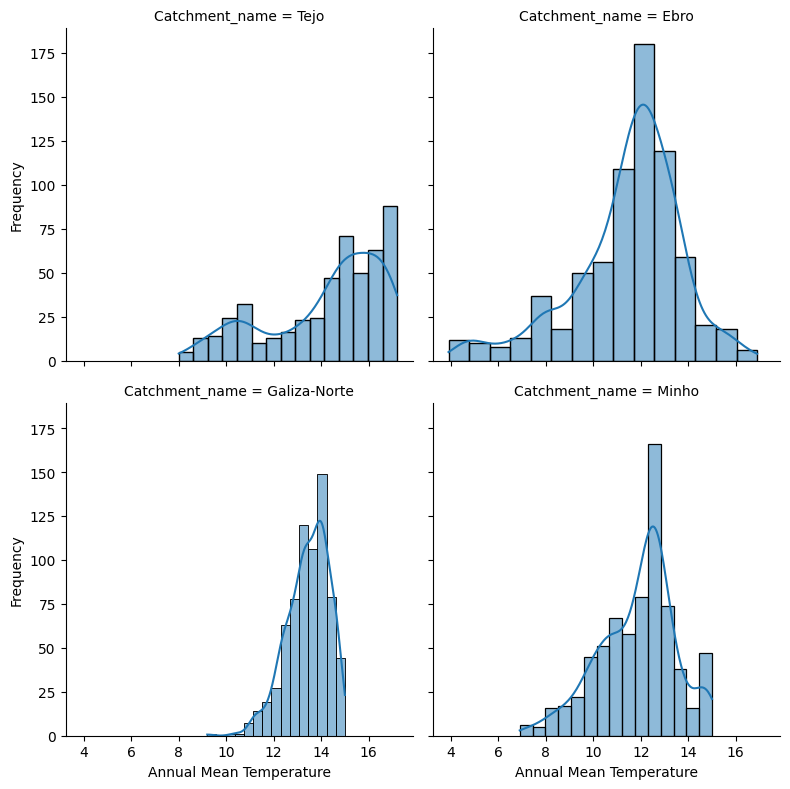

In [16]:
g = sns.FacetGrid(df_top4, col="Catchment_name", col_wrap=2, height=4)

g.map_dataframe(sns.histplot, x="temp_ann", bins=15, kde=True)

g.set_axis_labels("Annual Mean Temperature", "Frequency")

plt.show()

Violin Plot (Additional Plot)

/tmp/ipykernel_892/1728747776.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


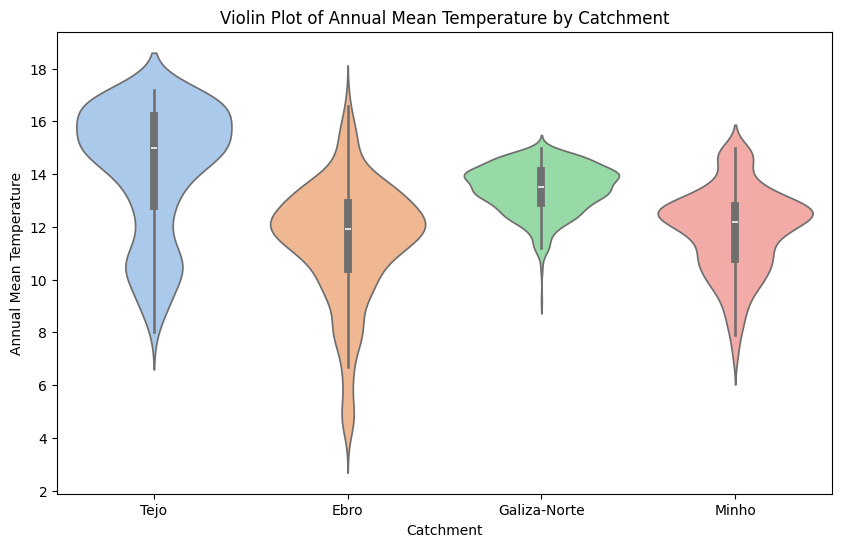

In [17]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_top4,
    x="Catchment_name",
    y="temp_ann",
    palette="pastel"
)

plt.title("Violin Plot of Annual Mean Temperature by Catchment")
plt.xlabel("Catchment")
plt.ylabel("Annual Mean Temperature")

plt.show()

Question 2: Evaluation of the Three Plot Types (Pros and Cons)
The three univariate visualizations used were: Boxplot, Strip plot and Histogram.

1. Boxplot

**Pros**

a. It Provides a compact summary of the distribution.   
b. It is easy to compare multiple groups on the boxplot   
c. It is very easy to identfy outliers clearly.   
d. It shows spread and central tendency efficiently.   
**Cons**

a. It does not show the detailed shape of the distribution.   
b. The individual data points are hidden and can create confusion for someone not familiar with its interpretations.   
c. It can be misleading with small samples or multimodal data, as the same box can represent very different distributions.

2. Strip plot

**Pros**.  
a. It shows every individual data point, preserving full transparency about the raw data.  
b. It reveals density patterns and gaps that box plots conceal — for instance, Galiza-Norte's tight clustering is immediately apparent.

**Cons**.  
a. It is harder to interpret distribution shape.  
b. It is harder to extract summary statistics at a glance compared to a box plot.  
c. It can become overcrowded with large datasets

3. Histogram

**Pros**

a. It is the best of the three for revealing distributional shape.  
b. It is easy to identify clusters and gaps in the data.   
c. Frequency on the y-axis gives an intuitive sense of data volume per catchment.

**Cons**

a. Exact values of observations are not visible.   
b. Bin width choices heavily influence interpretation — too wide or too narrow can distort the apparent shape.  
c. Comparing across catchments requires side-by-side panels, making direct comparison more effortful than the box plot.  
d. Takes the most space of the three, and the faceted layout makes cross-catchment comparison less immediate.



Question 3: Construct a plot that shows how the mean value of temp_ann varies with the size of random samplings of sites. Take 1000 random samples with replacement of increasing sample sizes (e.g. 10, 50, 100, 150, 200, 250, 300, 500 and 1000 observations), compute the mean Temp_ann of each sample and use an appropriate visualization to show how many samples will we need to have a good estimate of the population mean

In [18]:
# Inspect the variable
df["temp_ann"].describe()


,temp_ann
count,4841.000000
mean,13.261950
std,2.172315
min,3.900000
25%,12.000000
50%,13.400000
75%,14.600000
max,18.300000


In [19]:
# Look at some actual values
df["temp_ann"].head(10)

,temp_ann
0,17.6
1,9.3
2,10.1
3,10.1
4,10.3
5,10.6
6,11.0
7,11.3
8,12.1
9,9.9


In [20]:
# prepare the population values
temp_values = df["temp_ann"].dropna()

In [21]:
# Sample sizes to test
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]

In [22]:
# Number of random samples
n_samples = 1000

results = []

for size in sample_sizes:

    for i in range(n_samples):

        sample = np.random.choice(temp_values, size=size, replace=True)

        sample_mean = sample.mean()

        results.append({
            "sample_size": size,
            "sample_mean": sample_mean
        })

In [23]:
# Convert to dataframe
sampling_df = pd.DataFrame(results)

sampling_df.head()

,sample_size,sample_mean
0,10,12.69
1,10,12.35
2,10,13.10
3,10,12.74
4,10,13.96


Visualization of the result using  Boxplot

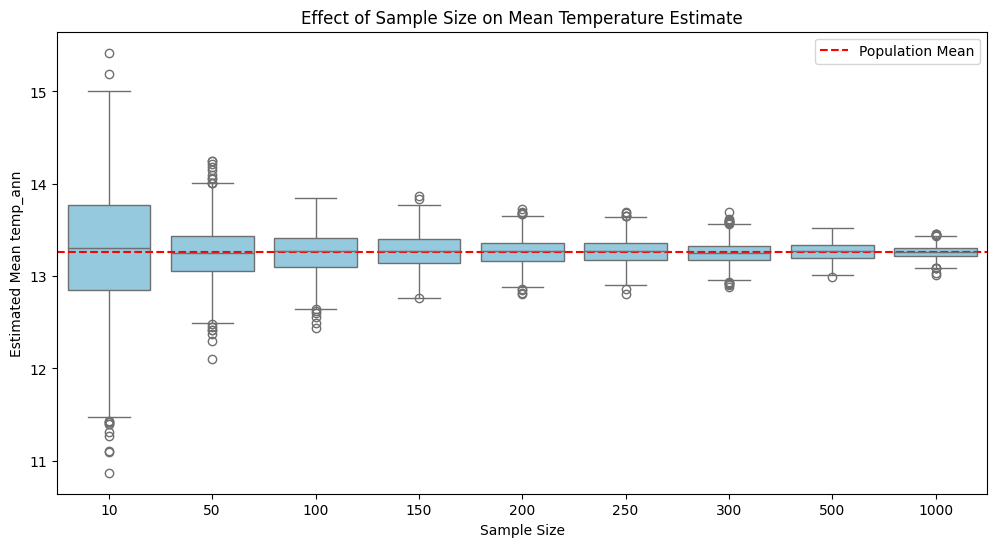

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=sampling_df,
    x="sample_size",
    y="sample_mean",
    color="skyblue"
)

plt.axhline(temp_values.mean(), color="red", linestyle="--", label="Population Mean")

plt.title("Effect of Sample Size on Mean Temperature Estimate")
plt.xlabel("Sample Size")
plt.ylabel("Estimated Mean temp_ann")

plt.legend()

plt.show()